In [488]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [489]:
df = pd.read_csv("cost_revenue_clean.csv")
x_train = pd.DataFrame(df, columns=["production_budget_usd"])
y_train = pd.DataFrame(df, columns=["worldwide_gross_usd"])
df

,production_budget_usd,worldwide_gross_usd
0,1000000,26
1,10000,401
2,400000,423
3,750000,450
4,10000,527
...,...,...
5029,225000000,1519479547
5030,215000000,1671640593
5031,306000000,2058662225
5032,200000000,2207615668


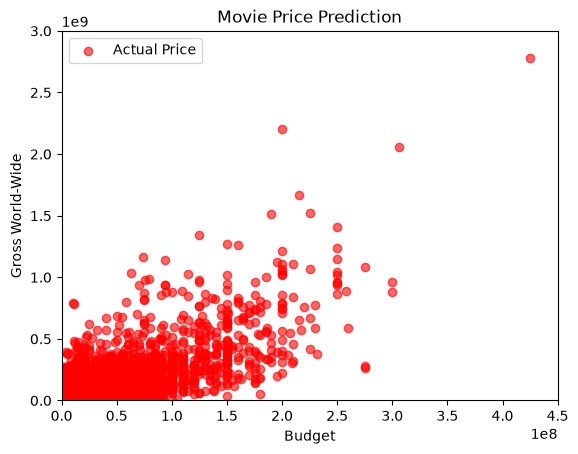

In [490]:
plt.scatter(x_train, y_train, marker="o", alpha=0.6, c="r", label="Actual Price")
plt.title("Movie Price Prediction")
plt.xlabel("Budget")
plt.ylabel("Gross World-Wide")
plt.xlim(0, 4.5e8)
plt.ylim(0, 3e9)
plt.legend()
plt.show()

#### y = mx + c -- Cost function where b= c and w = m usually

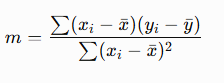

In [491]:
# Finding m (w)

# --  m = (∑[(xi​ - xˉ)(yi - yˉ​)]) - (∑(xi​ - xˉ)^2)

def compute_m(x, y):
    size = x.shape[0]
    numirator = 0
    denumirator = 0
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    for i in range(size):
        numirator += (x.iloc[i, 0] - x_mean) * (y.iloc[i, 0] - y_mean)
    for i in range(size):
        denumirator += (x.iloc[i, 0] - x_mean) ** 2
    return (numirator / denumirator)

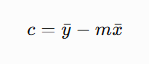

In [492]:
# Finding c (b)

# --  c = yˉ​− mxˉ

def compute_c(x, y, m):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    return ((y_mean) - (m * (x_mean)))

In [493]:
# y = mx + c

def compute_model_output(x, m, c):
    size = x.shape[0]
    y = np.zeros(size)
    for i in range(size):
        y[i] = (m * x.iloc[i, 0]) + c
    return y

In [494]:
m = compute_m(x_train, y_train)
c = compute_c(x_train, y_train, m)
print(f"m = {m}        c = {c}")

m = 3.111509182936116        c = -7236192.729139224


In [495]:

predicted_y = compute_model_output(x_train, m, c)
predicted_y = pd.DataFrame(predicted_y, columns=["Numbers"])
predicted_y

,Numbers
0,-4.124684e+06
1,-7.205078e+06
2,-5.991589e+06
3,-4.902561e+06
4,-7.205078e+06
...,...
5029,6.928534e+08
5030,6.617383e+08
5031,9.448856e+08
5032,6.150656e+08


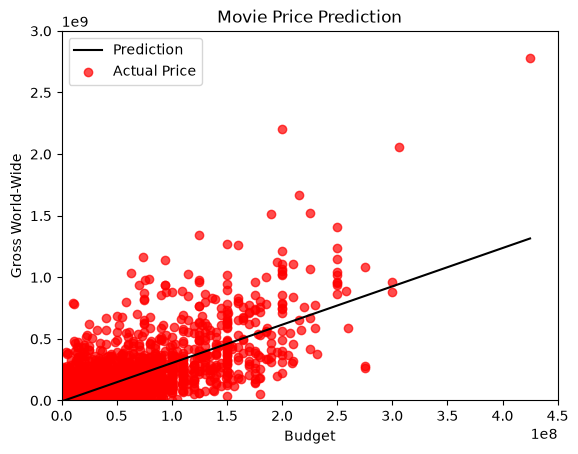

In [496]:
plt.plot(x_train, predicted_y, c="k", alpha=1, label="Prediction")
plt.scatter(x_train, y_train, marker="o", alpha=0.7, c="r", label="Actual Price")
plt.title("Movie Price Prediction")
plt.xlabel("Budget")
plt.ylabel("Gross World-Wide")
plt.xlim(0, 4.5e8)
plt.ylim(0, 3e9)
plt.legend()
plt.show()

In [497]:
budget = 5e6
prediction = (m * budget) + c 
prediction

np.float64(8321353.185541356)

#### R² (R-squared) 

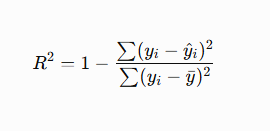

In [498]:
# R² (R-squared)

# --  R² = 1 - (∑(yi - y^​i​)^2 / ∑(yi - yˉ​)^2)

def compute_score(y, p_y):
    numirator = 0
    denumirator = 0
    y_mean = np.mean(y)
    size = y.shape[0]
    for i in range(size):
        numirator += ((y.iloc[i, 0] - p_y.iloc[i, 0]) ** 2)
    for i in range(size):
        denumirator += ((y.iloc[i, 0] - y_mean) ** 2)
    return (1 - (numirator / denumirator))

In [499]:
R_sqr = compute_score(y_train, predicted_y)
R_sqr

np.float64(0.5496485356985725)

<p>If we have more than 1 features then we have use this formula or we also can use this formula for every number of features:
</p>

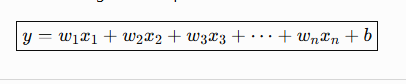
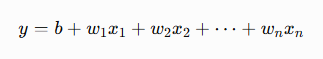

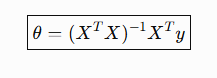

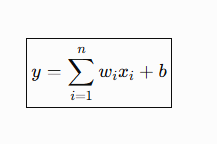

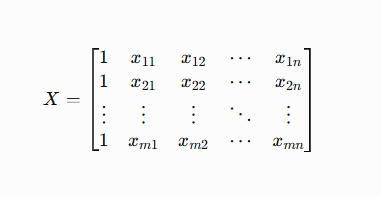

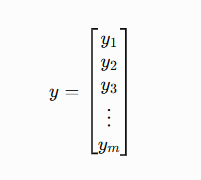

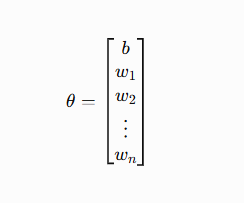

In [500]:

df

,production_budget_usd,worldwide_gross_usd
0,1000000,26
1,10000,401
2,400000,423
3,750000,450
4,10000,527
...,...,...
5029,225000000,1519479547
5030,215000000,1671640593
5031,306000000,2058662225
5032,200000000,2207615668


In [501]:
df.insert(0, "Biased", 1)

In [502]:
df

,Biased,production_budget_usd,worldwide_gross_usd
0,1,1000000,26
1,1,10000,401
2,1,400000,423
3,1,750000,450
4,1,10000,527
...,...,...,...
5029,1,225000000,1519479547
5030,1,215000000,1671640593
5031,1,306000000,2058662225
5032,1,200000000,2207615668


In [503]:
matrix_x = df.to_numpy()[1::, 0:2:]
matrix_y = df.to_numpy()[1::, -1]

In [504]:

matrix_x = matrix_x.astype(np.float64)
matrix_x

array([[1.00e+00, 1.00e+04],
       [1.00e+00, 4.00e+05],
       [1.00e+00, 7.50e+05],
       ...,
       [1.00e+00, 3.06e+08],
       [1.00e+00, 2.00e+08],
       [1.00e+00, 4.25e+08]], shape=(5033, 2))

In [505]:
matrix_y = matrix_y.reshape(-1, 1)
matrix_y = matrix_y.astype(np.float64)
matrix_y

array([[4.01000000e+02],
       [4.23000000e+02],
       [4.50000000e+02],
       ...,
       [2.05866222e+09],
       [2.20761567e+09],
       [2.78391898e+09]], shape=(5033, 1))

In [506]:
transpose_x = np.transpose(matrix_x)

In [507]:
temp_1 = transpose_x @ matrix_x
temp_1

array([[5.03300000e+03, 1.65657060e+11],
       [1.65657060e+11, 1.39639552e+19]])

In [508]:
inverse_temp_1 = np.linalg.inv(temp_1)
inverse_temp_1

array([[ 3.25968748e-04, -3.86702934e-12],
       [-3.86702934e-12,  1.17488254e-19]])

In [509]:
theta = inverse_temp_1 @ transpose_x
theta = theta @ matrix_y

In [510]:
theta

array([[-7.23752131e+06],
       [ 3.11152465e+00]])

In [511]:
b, w = theta.flatten()

In [512]:
print(f"b = {b} and w = {w}")

b = -7237521.305174472 and w = 3.111524648704034


In [513]:
predicted_y

,Numbers
0,-4.124684e+06
1,-7.205078e+06
2,-5.991589e+06
3,-4.902561e+06
4,-7.205078e+06
...,...
5029,6.928534e+08
5030,6.617383e+08
5031,9.448856e+08
5032,6.150656e+08


In [514]:
p_y = compute_model_output(x_train, w, b)
p_y

array([-4.12599666e+06, -7.20640606e+06, -5.99291145e+06, ...,
        9.44889021e+08,  6.15067408e+08,  1.31516045e+09], shape=(5034,))

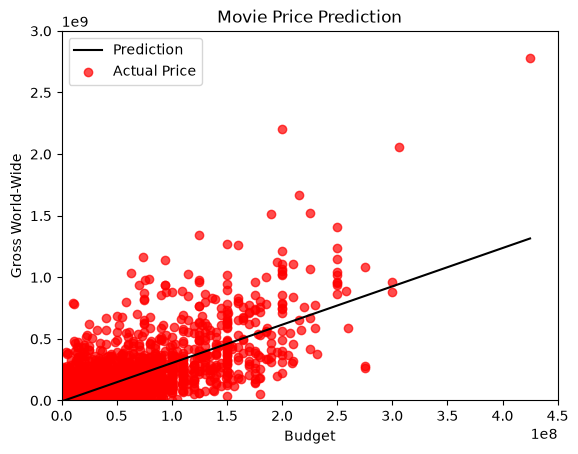

In [515]:
plt.plot(x_train, p_y, c="k", alpha=1, label="Prediction")
plt.scatter(x_train, y_train, marker="o", alpha=0.7, c="r", label="Actual Price")
plt.title("Movie Price Prediction")
plt.xlabel("Budget")
plt.ylabel("Gross World-Wide")
plt.xlim(0, 4.5e8)
plt.ylim(0, 3e9)
plt.legend()
plt.show()

In [516]:
py = pd.DataFrame(p_y, columns=["py"])

In [517]:
pppp = compute_score(y_train, py)

In [518]:
pppp

np.float64(0.5496485356624383)

# Cost Function

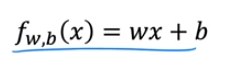

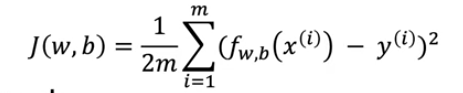

In [519]:
def linearModel(x, m, c):
    y = (m * x) + c
    return y

def compute_cost_func(x, y, m, c):
    j_sum = 0
    size = x.shape[0]
    for i in range(size):
        j_sum += (linearModel(x.iloc[i, 0], m, c) - y.iloc[i, 0]) ** 2
    return (j_sum / (2 * size))

def normalize_data(x, y):
    x_mean = x.mean()
    x_std = x.std()
    y_mean = y.mean()
    y_std = y.std()
    x_normalized = (x - x_mean) / x_std
    y_normalized = (y - y_mean) / y_std
    
    return (x_normalized, y_normalized)

In [520]:
x_norm, y_norm  = normalize_data(x_train, y_train)

In [521]:
cost_normalized = compute_cost_func(x_norm, y_norm, m, c)

cost = compute_cost_func(x_train, y_train, m, c)


In [522]:
print(f" cost : {cost:.6e}     normalized cost : {cost_normalized:.6e}")

 cost : 6.706918e+15     normalized cost : 2.618124e+13


In [523]:
print(f"x max: {x_train.max().values[0]}, y max: {y_train.max().values[0]}")
print(f"x min: {x_train.min().values[0]}, y min: {y_train.min().values[0]}")

x max: 425000000, y max: 2783918982
x min: 1100, y min: 26
